In [1]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
#!/bin/bash
!kaggle datasets download sumeakash/impact-of-social-media-on-health

Dataset URL: https://www.kaggle.com/datasets/sumeakash/impact-of-social-media-on-health
License(s): MIT
100% 18.2k/18.2k [00:00<00:00, 35.2MB/s]



In [3]:
!unzip /content/impact-of-social-media-on-health.zip

Archive:  /content/impact-of-social-media-on-health.zip
  inflating: Social_media_impact_on_life.csv  


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/Social_media_impact_on_life.csv")
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...,...
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive


In [6]:
df.shape

(1705, 11)

# Descriptive Statistics — Key Findings

In [7]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


- Dataset contains 1705 students. Student_ID excluded from analysis.

- Age (18–24, mean ≈ 21) confirms a young student population
  with an approximately symmetric distribution.

- Avg_Daily_Usage_Hours (mean ≈ 5.1, std = 1.68) indicates most
  students spend considerable time on digital platforms daily.

- Sleep_Hours_Per_Night (mean ≈ 6.6) falls below the recommended
  7–9 hours for young adults — a pattern worth investigating.

- Mental_Health_Score is treated as the target variable (range: 4–9,
  mean ≈ 6.2). Higher scores indicate better mental well-being.

- Core hypothesis: higher daily usage → lower mental health scores.
  This will be tested in subsequent sections.

# Data Types & Missing Values — Key Findings

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


In [9]:
df.isna().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


- All 11 columns have correct data types with zero missing values —
  no type conversion or imputation is required.

- 5 categorical and 1 ID column require value_counts() inspection
  to check for formatting inconsistencies and class distributions.

- Country column warrants attention — the number of unique values
  will determine whether it can be meaningfully used in analysis.

# Value Counts — Key Findings

In [10]:
for col in df.select_dtypes(include='object').columns:
    if col == 'Country':
        print(f"\nCountry (Top 10):")
        print(df['Country'].value_counts(dropna=False).head(10).to_string())
    else:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).to_string())
    print()


Gender:
Gender
Male      878
Female    827


Academic_Level:
Academic_Level
Undergraduate    721
Graduate         632
High School      352


Country (Top 10):
Country
Other        667
India        139
USA          115
Canada        78
Australia     66
UK            66
Germany       46
Spain         27
Mexico        27
France        27


Most_Used_Platform:
Most_Used_Platform
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
VKontakte     12
KakaoTalk     12


Affects_Academic_Performance:
Affects_Academic_Performance
Yes    1011
No      694


Overall_Impact:
Overall_Impact
Negative    939
Positive    499
Neutral     267



- Gender is nearly balanced — no class imbalance concerns.

- Undergraduate students dominate (42%), followed by Graduate (37%)
  and High School (21%).

- Country contains 111 unique values with "Other" as the largest group
  (667 students) — only top countries will be used where relevant.

- 59% of students report that platform usage negatively affects their
  academic performance.

- Overall_Impact is predominantly Negative (55%), with Positive (29%)
  and Neutral (16%) — suggesting digital usage is more harmful
  than beneficial for most students.

# Dataset Overview


In [11]:
df.head(10)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
5,370,19,Female,High School,Other,4.1,Twitter,Yes,6.8,6.8,Neutral
6,862,22,Female,Graduate,Other,8.0,Instagram,Yes,5.2,5.3,Negative
7,520,21,Female,Graduate,Other,6.0,Facebook,Yes,5.7,4.7,Negative
8,703,24,Male,Undergraduate,USA,4.7,YouTube,No,7.0,6.2,Neutral
9,33,19,Male,High School,Other,3.6,TikTok,No,8.1,8.6,Positive


# Dataset Column Descriptions

| Column | Type | Description |
|---|---|---|
| Student_ID | Numeric | Unique identifier — excluded from analysis |
| Age | Numeric | Student age (18–24) |
| Avg_Daily_Usage_Hours | Numeric | Average daily hours spent on digital platforms |
| Sleep_Hours_Per_Night | Numeric | Average nightly sleep hours |
| Mental_Health_Score | Numeric | Mental well-being score (4–9) — target variable |
| Gender | Categorical | Male / Female |
| Academic_Level | Categorical | High School / Undergraduate / Graduate |
| Country | Categorical | Country of the student (111 unique values) |
| Most_Used_Platform | Categorical | Most frequently used digital platform |
| Affects_Academic_Performance | Categorical | Whether usage affects academic performance (Yes / No) |
| Overall_Impact | Categorical | Overall effect of usage (Positive / Neutral / Negative) |

## Notes
- Observational dataset — relationships indicate correlation, not causation.
- No missing values. No type conversion required.
- Goal: understand which factors are associated with better or worse
  mental health scores among students.

In [12]:
top_countries = df['Country'].value_counts().head(10).index
df['Country_Group'] = df['Country'].apply(
    lambda x: x if x in top_countries else 'Other')

print(df['Country_Group'].value_counts())

Country_Group
Other        1114
India         139
USA           115
Canada         78
Australia      66
UK             66
Germany        46
France         27
Spain          27
Mexico         27
Name: count, dtype: int64


# Numeric Features — Univariate Analysis

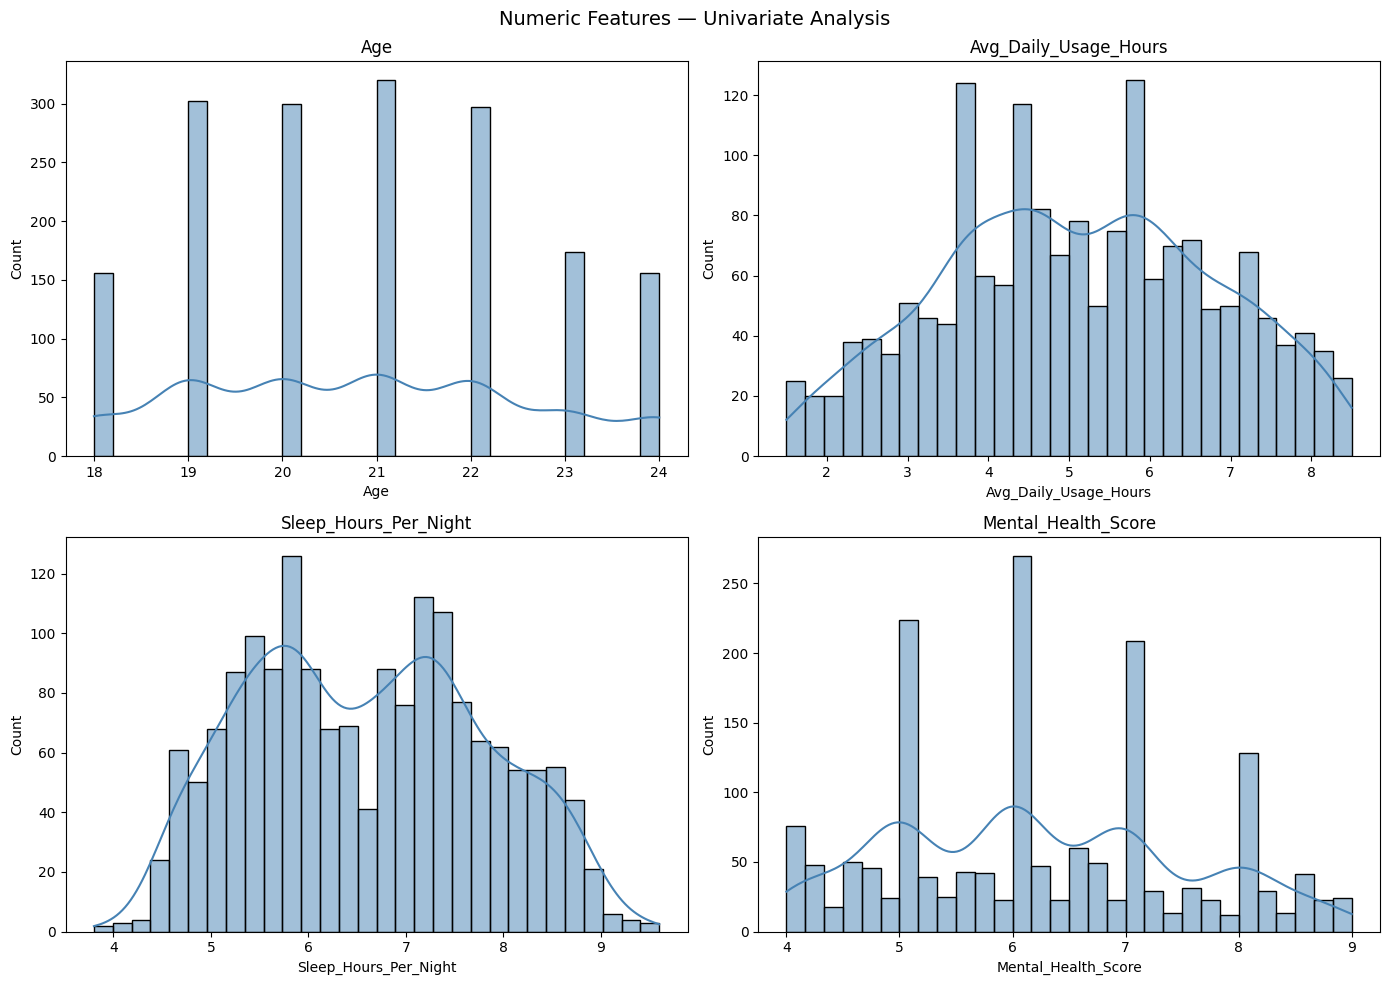

In [13]:
numeric_cols = ['Age', 'Avg_Daily_Usage_Hours',
                'Sleep_Hours_Per_Night', 'Mental_Health_Score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Features — Univariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Age distribution is concentrated between 19–22, reflecting a typical
  undergraduate student population. Ages 18 and 24 are less common.

- Avg_Daily_Usage_Hours shows a bimodal distribution with two distinct
  peaks around 4 and 6 hours, suggesting students fall into two groups:
  moderate users and intensive users.

- Sleep_Hours_Per_Night also appears bimodal — one group sleeping ~5–6
  hours and another ~7–8 hours, with few students in between.

- Mental_Health_Score clusters around whole numbers (5, 6, 8), showing
  a round number effect similar to the previous dataset — a potential
  indicator of synthetic data.

---

# Categorical Features — Univariate Analysis

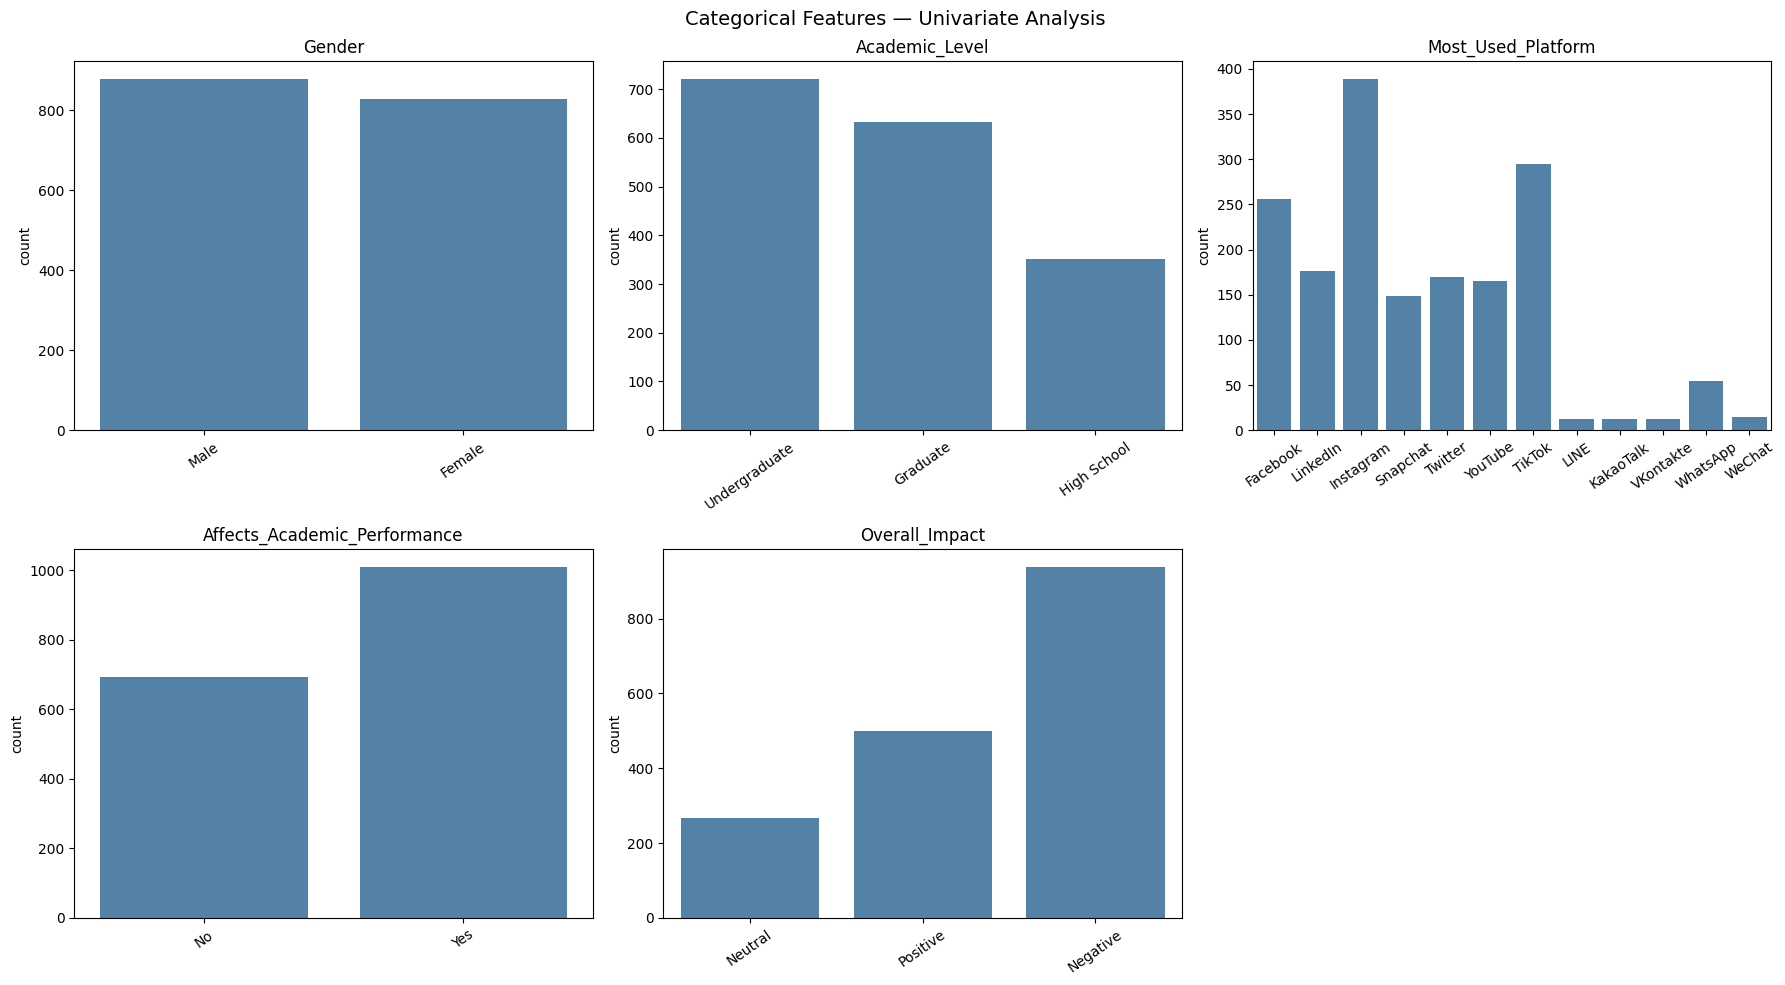

In [14]:
categorical_cols = ['Gender', 'Academic_Level', 'Most_Used_Platform',
                    'Affects_Academic_Performance', 'Overall_Impact']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)

axes[-1].set_visible(False)

plt.suptitle('Categorical Features — Univariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Gender is balanced, Academic_Level is dominated by Undergraduates (42%).

- Most_Used_Platform is led by entertainment platforms — Instagram,
  TikTok, and Facebook. LinkedIn is the only professional platform
  in the top group, which may relate differently to mental health outcomes.

- 59% report academic performance is affected, and 55% report an
  overall negative impact from platform usage.

---

# Numeric Features vs Mental Health Score — Bivariate Analysis

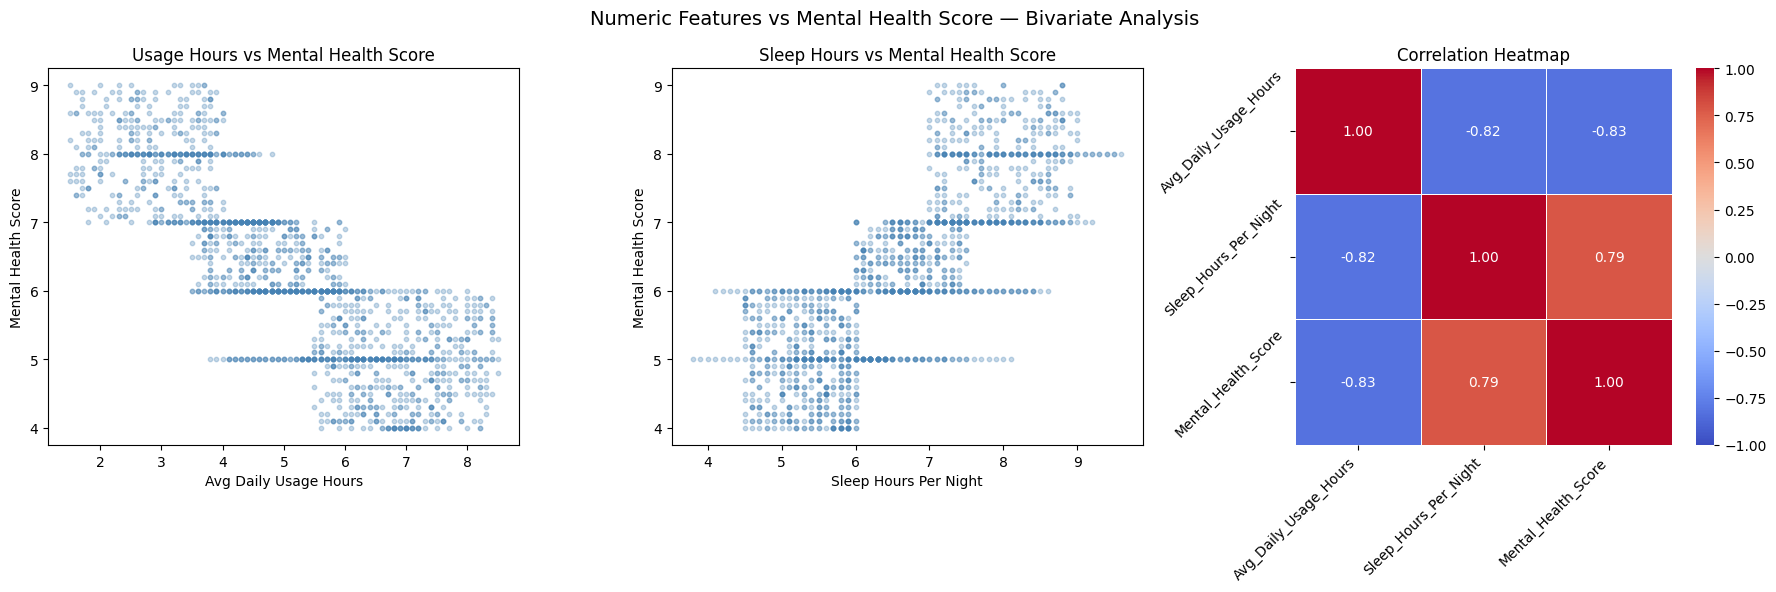

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(df['Avg_Daily_Usage_Hours'], df['Mental_Health_Score'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Avg Daily Usage Hours')
axes[0].set_ylabel('Mental Health Score')
axes[0].set_title('Usage Hours vs Mental Health Score')

axes[1].scatter(df['Sleep_Hours_Per_Night'], df['Mental_Health_Score'],
                alpha=0.3, color='steelblue', s=10)
axes[1].set_xlabel('Sleep Hours Per Night')
axes[1].set_ylabel('Mental Health Score')
axes[1].set_title('Sleep Hours vs Mental Health Score')

corr = df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
           'Mental_Health_Score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, ax=axes[2],
            xticklabels=True, yticklabels=True)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=45, ha='right')
axes[2].set_title('Correlation Heatmap')

plt.suptitle('Numeric Features vs Mental Health Score — Bivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Avg_Daily_Usage_Hours shows a strong negative correlation with
  Mental_Health_Score (r = -0.83) — the strongest relationship in
  the dataset. Students spending 2–3 hours daily report noticeably
  higher mental well-being, while 6+ hours is associated with
  significantly lower scores.

- Sleep_Hours_Per_Night shows a strong positive correlation with
  Mental_Health_Score (r = 0.79) — more sleep consistently leads
  to better mental health outcomes.

- Critically, Usage_Hours and Sleep_Hours are also strongly negatively
  correlated (r = -0.82), suggesting that excessive screen time
  reduces sleep, which in turn further damages mental health.
  This indicates a compounding effect: more usage → less sleep →
  worse mental health.

- These three variables form a clear chain of influence, making
  daily usage hours the primary behavioral risk factor in this dataset.


---

# Categorical Features vs Mental Health Score — Bivariate Analysis

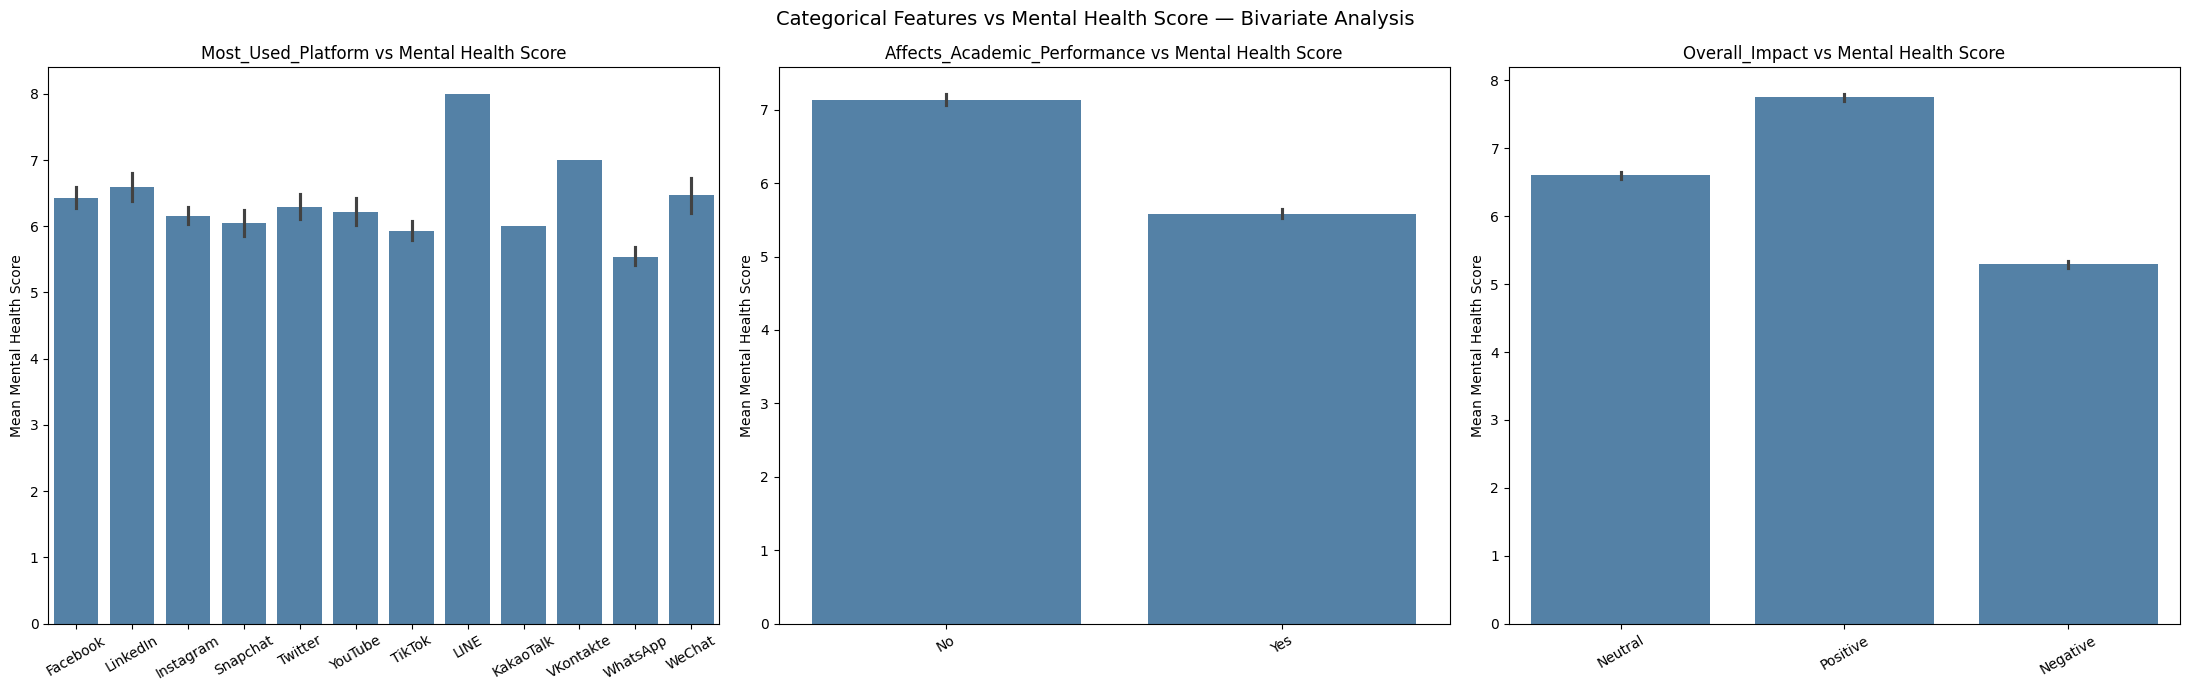

In [16]:
categorical_cols = ['Most_Used_Platform',
                    'Affects_Academic_Performance', 'Overall_Impact']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, col in enumerate(categorical_cols):
    sns.barplot(x=df[col], y=df['Mental_Health_Score'],
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} vs Mental Health Score')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Mean Mental Health Score')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Features vs Mental Health Score — Bivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Gender and Academic_Level show negligible differences in mental
  health scores and were excluded from this analysis.

- Most_Used_Platform shows minimal variation across platforms —
  no single platform stands out as significantly more harmful or
  beneficial. WhatsApp's lower score should be interpreted cautiously
  due to its small user count in this dataset.

- Affects_Academic_Performance reveals a meaningful threshold effect:
  students whose usage does not affect academics score 7.1, while
  those reporting an impact score 5.6. This suggests a mental health
  score below 5.5 may signal academic risk.

- Overall_Impact shows the strongest categorical pattern: Positive
  impact (7.7) vs Negative impact (5.1) — a 2.6 point gap, the
  largest difference observed across all categorical variables.
  A score below 5.0 appears to correspond with negative overall outcomes.

---

# Usage Hours + Sleep Hours — Multivariate Analysis

/tmp/ipykernel_16431/2207179598.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['Usage_Group', 'Sleep_Group'])['Mental_Health_Score'].mean().unstack()


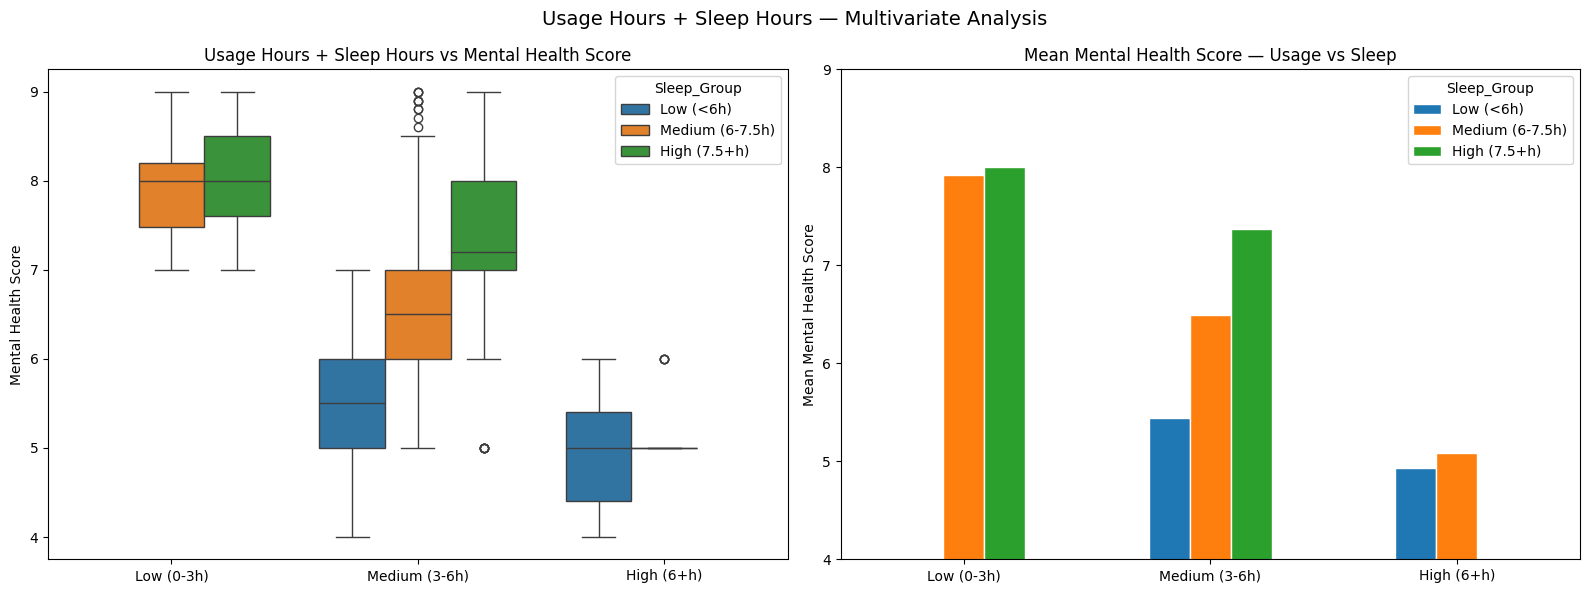

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['Usage_Group'] = pd.cut(df['Avg_Daily_Usage_Hours'],
                            bins=[0, 3, 6, 9],
                            labels=['Low (0-3h)', 'Medium (3-6h)', 'High (6+h)'])

df['Sleep_Group'] = pd.cut(df['Sleep_Hours_Per_Night'],
                            bins=[0, 6, 7.5, 10],
                            labels=['Low (<6h)', 'Medium (6-7.5h)', 'High (7.5+h)'])

sns.boxplot(x=df['Usage_Group'], y=df['Mental_Health_Score'],
            hue=df['Sleep_Group'], ax=axes[0])
axes[0].set_title('Usage Hours + Sleep Hours vs Mental Health Score')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mental Health Score')

pivot = df.groupby(['Usage_Group', 'Sleep_Group'])['Mental_Health_Score'].mean().unstack()
pivot.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Mean Mental Health Score — Usage vs Sleep')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Mental Health Score')
axes[1].set_ylim(4, 9)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Usage Hours + Sleep Hours — Multivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- When daily usage is low (0-3h), sleep quality matters less —
  both medium and high sleep groups score similarly high (around 8.0),
  suggesting that limited screen time alone is sufficient to maintain
  good mental health.

- When usage is moderate (3-6h), sleep becomes a critical differentiator:
  low sleep scores around 5.5 vs high sleep around 7.4 — a 2 point gap.
  Managing sleep becomes essential at this usage level.

- When usage is high (6+h), sleep loses its protective effect entirely.
  Even students sleeping 7.5+ hours score only around 5.1 — nearly
  identical to low sleepers (around 4.9). This suggests a tipping point
  beyond which no amount of sleep can compensate for excessive screen time.

- Notably, low sleep is virtually absent in the low usage group,
  visually confirming the strong negative correlation (r = -0.82)
  between usage hours and sleep hours found earlier.

---

# Platform + Academic Level — Multivariate Analysis

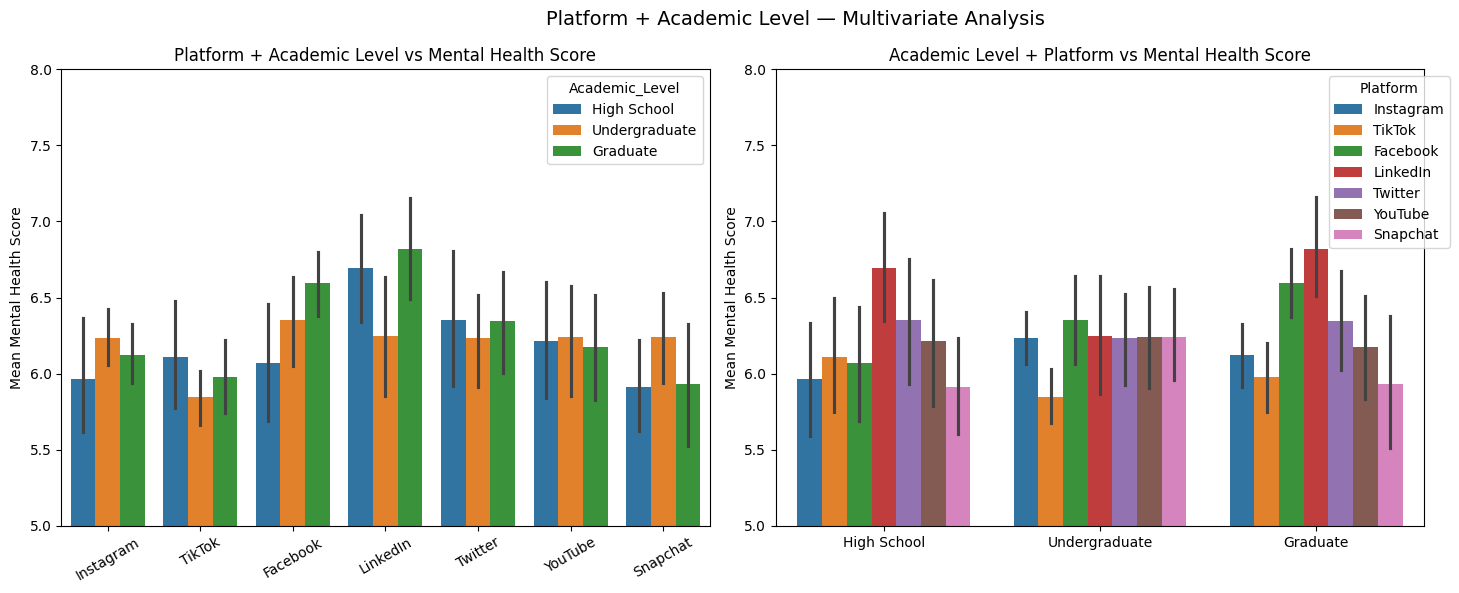

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_level = ['High School', 'Undergraduate', 'Graduate']
order_platform = ['Instagram', 'TikTok', 'Facebook',
                  'LinkedIn', 'Twitter', 'YouTube', 'Snapchat']

df_top = df[df['Most_Used_Platform'].isin(order_platform)]

sns.barplot(x='Most_Used_Platform', y='Mental_Health_Score',
            hue='Academic_Level', data=df_top,
            ax=axes[0], hue_order=order_level, order=order_platform)
axes[0].set_title('Platform + Academic Level vs Mental Health Score')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Mental Health Score')
axes[0].set_ylim(5, 8)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x='Academic_Level', y='Mental_Health_Score',
            hue='Most_Used_Platform', data=df_top,
            ax=axes[1], order=order_level, hue_order=order_platform)
axes[1].set_title('Academic Level + Platform vs Mental Health Score')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Mental Health Score')
axes[1].set_ylim(5, 8)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Platform', bbox_to_anchor=(1.05, 1))

plt.suptitle('Platform + Academic Level — Multivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- LinkedIn consistently shows the highest mental health scores across
  all academic levels, likely because it is used for professional and
  academic purposes rather than passive entertainment.

- TikTok and Snapchat show the lowest scores across all groups —
  both are entertainment-focused platforms with addictive design patterns.

- Academic level has minimal influence within each platform — the
  choice of platform matters more than the student's education level
  for mental health outcomes.

---

# Hypothesis Test 1 — Independent T-Test

In [19]:
from scipy import stats

# Yüksək istifadə (6+) vs Aşağı istifadə (0-3)
high_usage = df[df['Avg_Daily_Usage_Hours'] >= 6]['Mental_Health_Score']
low_usage = df[df['Avg_Daily_Usage_Hours'] <= 3]['Mental_Health_Score']

t_stat, p_value = stats.ttest_ind(high_usage, low_usage)

print(f"High usage group mean: {high_usage.mean():.2f}")
print(f"Low usage group mean: {low_usage.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Statistically significant difference (p < 0.05)")
else:
    print("\nResult: No statistically significant difference (p > 0.05)")

High usage group mean: 4.97
Low usage group mean: 7.98
T-statistic: -63.8823
P-value: 0.000000

Result: Statistically significant difference (p < 0.05)


**Research question:** Do students with high daily usage (6+ hours)
have significantly lower mental health scores than low users (0–3 hours)?

- H₀ (Null hypothesis): There is no significant difference in mental
  health scores between high and low usage groups.
- H₁ (Alternative hypothesis): High usage students have significantly
  lower mental health scores.

**Results:**
- Low usage group mean: 7.98
- High usage group mean: 4.97
- T-statistic: -63.88
- P-value: ≈ 0.000 (p < 0.05)

**Conclusion:** H₀ is rejected. The difference is statistically
significant — students spending 6+ hours daily on digital platforms
score approximately 3 points lower on mental health than those
spending 3 hours or less. This is the strongest finding in the analysis.

------------------------

# Hypothesis Test 2 — One-Way ANOVA

In [20]:
from scipy import stats

platforms = ['Instagram', 'TikTok', 'Facebook', 'LinkedIn', 'Twitter', 'YouTube', 'Snapchat']

groups = [df[df['Most_Used_Platform'] == p]['Mental_Health_Score'] for p in platforms]

f_stat, p_value = stats.f_oneway(*groups)

print("Mean Mental Health Score by Platform:")
for p in platforms:
    mean = df[df['Most_Used_Platform'] == p]['Mental_Health_Score'].mean()
    print(f"  {p}: {mean:.2f}")

print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Statistically significant difference (p < 0.05)")
else:
    print("\nResult: No statistically significant difference (p > 0.05)")

Mean Mental Health Score by Platform:
  Instagram: 6.16
  TikTok: 5.93
  Facebook: 6.43
  LinkedIn: 6.60
  Twitter: 6.30
  YouTube: 6.21
  Snapchat: 6.05

F-statistic: 6.7075
P-value: 0.000000

Result: Statistically significant difference (p < 0.05)


**Research question:** Is there a statistically significant difference
in mental health scores across different social media platforms?

- H₀: There is no significant difference in mental health scores
  across platforms.
- H₁: At least one platform differs significantly in mental health outcomes.

**Results:**
- LinkedIn: 6.60 (highest)
- Facebook: 6.43
- Twitter: 6.30
- YouTube: 6.21
- Instagram: 6.16
- Snapchat: 6.05
- TikTok: 5.93 (lowest)
- F-statistic: 6.71
- P-value: ≈ 0.000 (p < 0.05)

**Conclusion:** H₀ is rejected — platform choice does have a
statistically significant effect on mental health. However, the
difference between platforms is modest (0.67 points between LinkedIn
and TikTok), far smaller than the 3-point gap observed between high
and low usage groups. This confirms that how much you use matters
far more than which platform you use.

---

# Hypothesis Test 3 — Pearson Correlation


In [21]:
from scipy import stats

# Usage Hours vs Mental Health
corr1, p1 = stats.pearsonr(df['Avg_Daily_Usage_Hours'], df['Mental_Health_Score'])

# Sleep Hours vs Mental Health
corr2, p2 = stats.pearsonr(df['Sleep_Hours_Per_Night'], df['Mental_Health_Score'])

# Usage Hours vs Sleep Hours
corr3, p3 = stats.pearsonr(df['Avg_Daily_Usage_Hours'], df['Sleep_Hours_Per_Night'])

print("Pearson Correlation Results:")
print(f"\nUsage Hours vs Mental Health Score:")
print(f"  r = {corr1:.4f}, p-value = {p1:.6f}")

print(f"\nSleep Hours vs Mental Health Score:")
print(f"  r = {corr2:.4f}, p-value = {p2:.6f}")

print(f"\nUsage Hours vs Sleep Hours:")
print(f"  r = {corr3:.4f}, p-value = {p3:.6f}")

Pearson Correlation Results:

Usage Hours vs Mental Health Score:
  r = -0.8264, p-value = 0.000000

Sleep Hours vs Mental Health Score:
  r = 0.7854, p-value = 0.000000

Usage Hours vs Sleep Hours:
  r = -0.8174, p-value = 0.000000


**Research question:** Are the relationships between usage hours,
sleep hours, and mental health scores statistically significant?

**Results:**
- Usage Hours vs Mental Health Score: r = -0.83, p ≈ 0.000
- Sleep Hours vs Mental Health Score: r = 0.79, p ≈ 0.000
- Usage Hours vs Sleep Hours: r = -0.82, p ≈ 0.000

**Conclusion:** All three correlations are statistically significant.
Together they reveal a clear chain of influence: excessive screen time
reduces sleep, which in turn further damages mental health. The effect
of usage hours on mental health is therefore both direct (-0.83) and
indirect through sleep reduction (-0.82), making daily usage hours
the single most critical behavioral risk factor in this dataset.

---

# Final Conclusion

This analysis demonstrates that the primary determinant of students'
mental health is daily screen time, which exerts both a strong direct
negative effect (r = -0.83) and an indirect effect by reducing sleep
duration (r = -0.82), creating a compounding impact on well-being.

## Key Findings

- Students limiting usage to 0–3 hours consistently achieve high mental
  health scores (8.0), while those exceeding 6 hours experience a sharp
  decline (5.0) — a critical threshold beyond which even adequate sleep
  fails to mitigate negative outcomes.

- Platform choice shows statistically significant differences (ANOVA,
  p < 0.05), but the effect size is minimal (0.67 points) compared to
  the nearly 3-point gap driven by usage intensity — how long matters
  far more than which platform.

- Students with mental health scores below 5.5 show increased academic
  risk, and those below 5.0 report predominantly negative overall impact,
  suggesting mental health and academic performance are closely linked.

## Limitations

- The dataset shows characteristics of synthetic data — round number
  effects and unusually clean distributions — which may understate
  real-world variability.
- Observational data only — causation cannot be confirmed, only correlation.

## Bottom Line

Effective intervention should prioritize reducing daily screen time
above all else. Usage hours represent the dominant behavioral risk
factor shaping student well-being — platform selection and isolated
lifestyle changes are secondary considerations at best.

In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 